In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# Load raw data again
df = pd.read_csv('../data/ai4i2020.csv')

sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Recreate rolling features
window_size = 10
for col in sensor_cols:
    df[f'{col}_roll_mean'] = df[col].rolling(window=window_size).mean()
    df[f'{col}_roll_std']  = df[col].rolling(window=window_size).std()
    df[f'{col}_roll_var']  = df[col].rolling(window=window_size).var()

df = df.dropna().reset_index(drop=True)

print(f"✅ Data loaded | Shape: {df.shape}")

✅ Data loaded | Shape: (9991, 29)


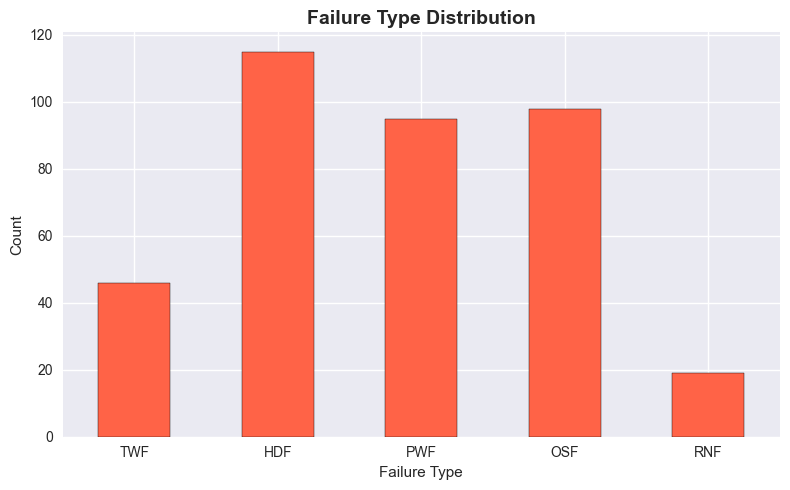

Failure Type Counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Total failure events: 339


In [3]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

failure_counts = df[failure_types].sum()

plt.figure(figsize=(8, 5))
failure_counts.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Failure Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('../src/failure_types.png')

plt.show()

print("Failure Type Counts:")
print(failure_counts)

print(f"\nTotal failure events: {df['Machine failure'].sum()}")

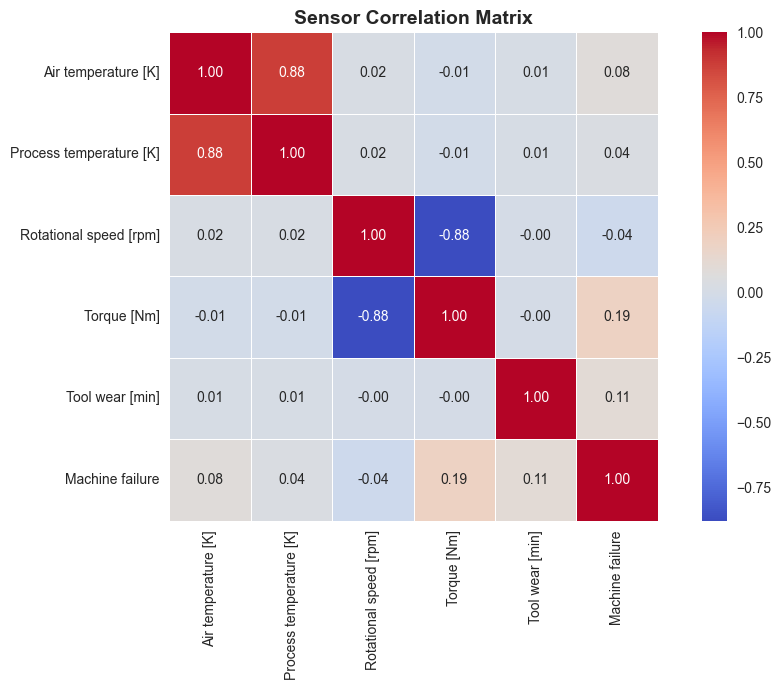

✅ Correlation heatmap saved!


In [4]:
corr_cols = sensor_cols + ['Machine failure']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title('Sensor Correlation Matrix',
          fontsize=14,
          fontweight='bold')

plt.tight_layout()

plt.savefig('../src/correlation_heatmap.png')

plt.show()

print("✅ Correlation heatmap saved!")

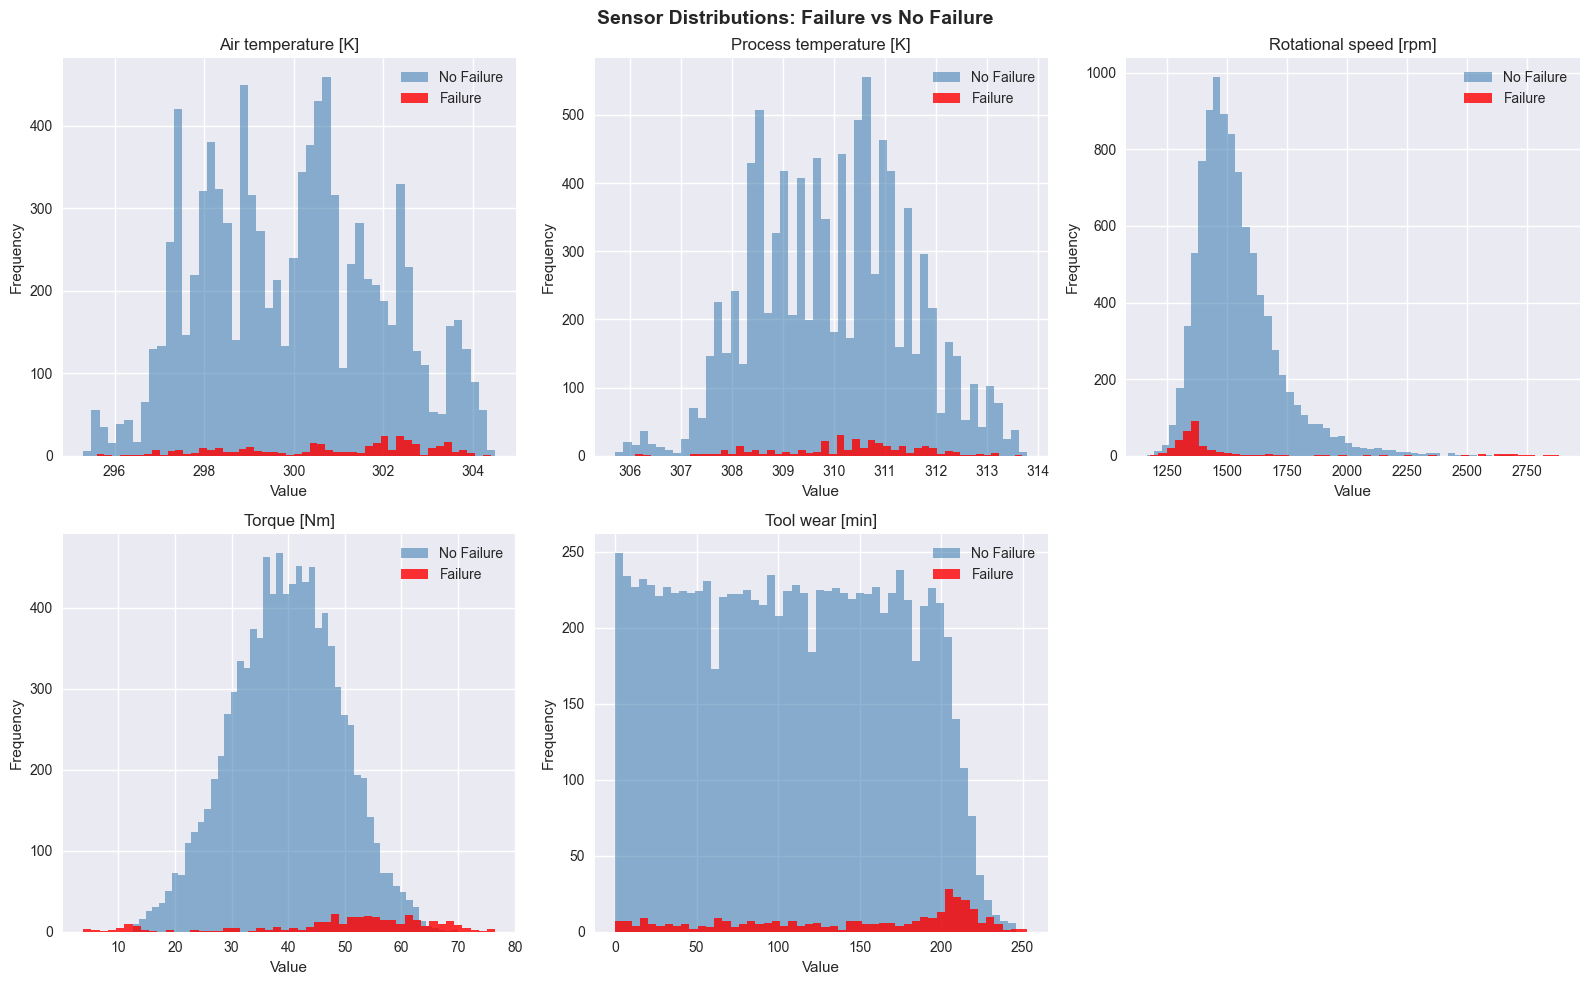

✅ Distribution plots saved!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):

    axes[i].hist(
        df[df['Machine failure'] == 0][col],
        bins=50,
        alpha=0.6,
        color='steelblue',
        label='No Failure'
    )

    axes[i].hist(
        df[df['Machine failure'] == 1][col],
        bins=50,
        alpha=0.8,
        color='red',
        label='Failure'
    )

    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

axes[-1].axis('off')

plt.suptitle(
    'Sensor Distributions: Failure vs No Failure',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig('../src/sensor_distributions.png')

plt.show()

print("✅ Distribution plots saved!")

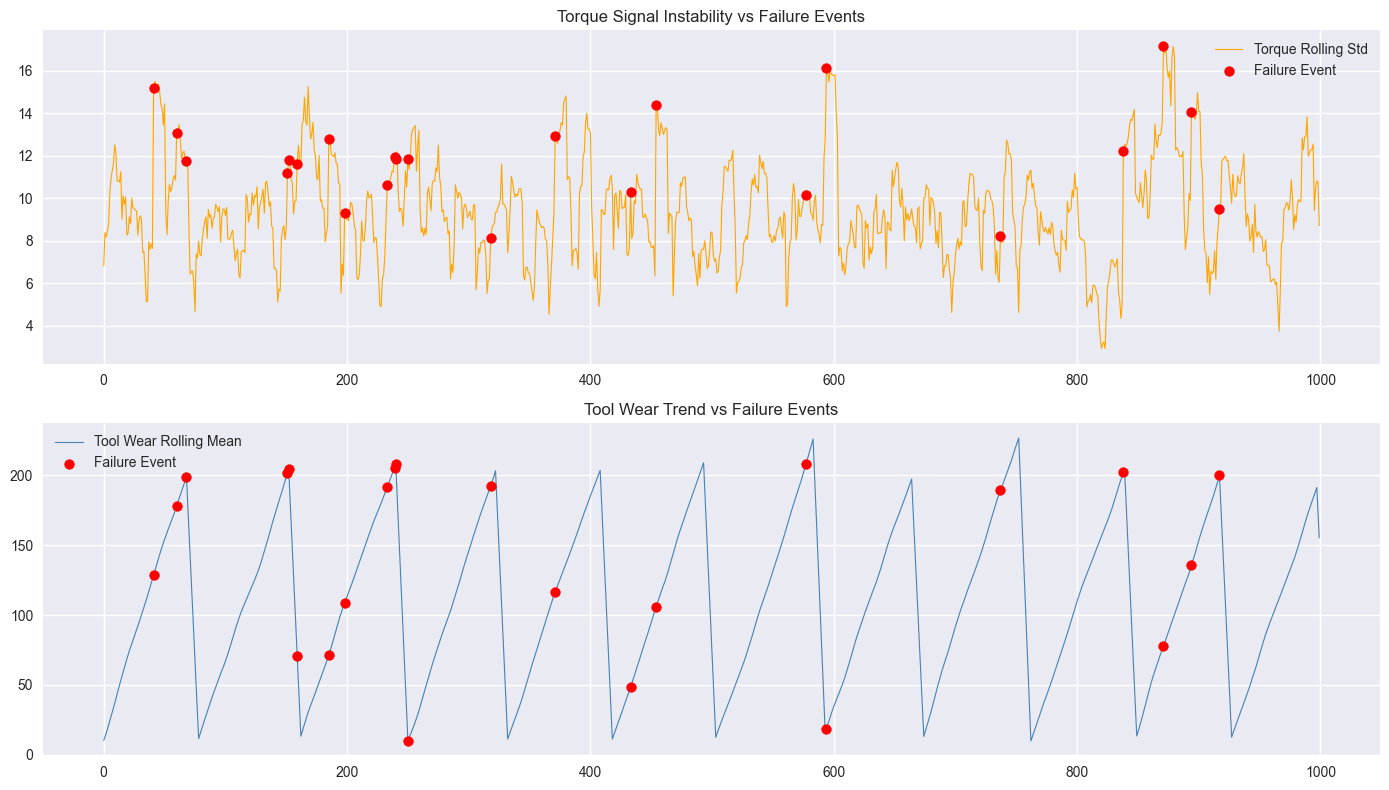

✅ Anomaly signal plots saved!


In [6]:
# High rolling std = unstable signal = possible failure sign

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Torque rolling std
axes[0].plot(
    df['Torque [Nm]_roll_std'].values[:1000],
    color='orange',
    linewidth=0.8,
    label='Torque Rolling Std'
)

# Failure points
failure_idx = df[df['Machine failure'] == 1].index
failure_idx_filtered = failure_idx[failure_idx < 1000]

axes[0].scatter(
    failure_idx_filtered,
    df.loc[
        failure_idx_filtered,
        'Torque [Nm]_roll_std'
    ],
    color='red',
    zorder=5,
    s=50,
    label='Failure Event'
)

axes[0].set_title(
    'Torque Signal Instability vs Failure Events'
)

axes[0].legend()


# Tool wear rolling mean
axes[1].plot(
    df['Tool wear [min]_roll_mean'].values[:1000],
    color='steelblue',
    linewidth=0.8,
    label='Tool Wear Rolling Mean'
)

axes[1].scatter(
    failure_idx_filtered,
    df.loc[
        failure_idx_filtered,
        'Tool wear [min]_roll_mean'
    ],
    color='red',
    zorder=5,
    s=50,
    label='Failure Event'
)

axes[1].set_title(
    'Tool Wear Trend vs Failure Events'
)

axes[1].legend()

plt.tight_layout()

plt.savefig('../src/anomaly_signals.png')

plt.show()

print("✅ Anomaly signal plots saved!")

In [7]:
summary = df.groupby(
    'Machine failure'
)[sensor_cols].mean().T

summary.columns = [
    'No Failure (Mean)',
    'Failure (Mean)'
]

summary['Difference %'] = (
    (
        summary['Failure (Mean)']
        -
        summary['No Failure (Mean)']
    )
    /
    summary['No Failure (Mean)']
    * 100
).round(2)

print(
    "=== Sensor Averages: "
    "Failure vs No Failure ==="
)

print(summary.to_string())

=== Sensor Averages: Failure vs No Failure ===
                         No Failure (Mean)  Failure (Mean)  Difference %
Air temperature [K]             299.975694      300.886431          0.30
Process temperature [K]         309.996850      310.290265          0.09
Rotational speed [rpm]         1540.300145     1496.486726         -2.84
Torque [Nm]                      39.628160       50.168142         26.60
Tool wear [min]                 106.784604      143.781711         34.65


In [8]:
insights = f"""
## Week 1 - Day 2 Findings

### Dataset Shape: {df.shape}
### Failure Rate: {df['Machine failure'].mean()*100:.2f}%

### Key Observations:
- Tool Wear and Torque show strong relation with failure
- Rolling Std spikes visible before failure events
- Failure types: TWF, HDF, PWF, OSF, RNF identified

### Features engineered so far:
- Rolling Mean (window=10)
- Rolling Std (window=10)
- Rolling Var (window=10)
"""

with open('../src/day2_insights.txt', 'w') as f:
    f.write(insights)

print("✅ Insights saved!")
print(insights)

✅ Insights saved!

## Week 1 - Day 2 Findings

### Dataset Shape: (9991, 29)
### Failure Rate: 3.39%

### Key Observations:
- Tool Wear and Torque show strong relation with failure
- Rolling Std spikes visible before failure events
- Failure types: TWF, HDF, PWF, OSF, RNF identified

### Features engineered so far:
- Rolling Mean (window=10)
- Rolling Std (window=10)
- Rolling Var (window=10)

